In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load ranking dataset
ranking_df = pd.read_csv("../processed_data/best_crop_mandi_ranking.csv")

# Standardize columns
ranking_df.columns = ranking_df.columns.str.strip().str.lower()

print("Dataset Loaded Successfully")
print("Shape:", ranking_df.shape)
ranking_df.head()

Dataset Loaded Successfully
Shape: (5182, 7)


,state,district,crop,predicted_yield,modal_price,expected_revenue,rank
0,Andhra Pradesh,Visakhapatnam,Turmeric,49.939109,11000.0,549330.203632,1.0
1,Andhra Pradesh,Visakhapatnam,Turmeric,48.592510,11000.0,534517.605607,2.0
2,Andhra Pradesh,Visakhapatnam,Turmeric,46.915402,11000.0,516069.422809,3.0
3,Andhra Pradesh,Visakhapatnam,Turmeric,46.670182,11000.0,513371.997936,4.0
4,Andhra Pradesh,Visakhapatnam,Turmeric,45.293171,11000.0,498224.875655,5.0


In [3]:
print("Total States:", ranking_df["state"].nunique())
print("Total Districts:", ranking_df["district"].nunique())
print("Total Crops:", ranking_df["crop"].nunique())

ranking_df.describe()

Total States: 15
Total Districts: 118
Total Crops: 12


,predicted_yield,modal_price,expected_revenue,rank
count,5182.000000,5182.000000,5.182000e+03,5182.000000
mean,41.648170,5451.113856,2.265919e+05,34.501930
std,7.154286,6045.565098,2.588707e+05,38.182622
min,27.465524,1250.000000,3.554190e+04,1.000000
25%,35.149150,2580.000000,1.172222e+05,9.000000
50%,42.662724,5250.000000,2.157806e+05,22.000000
75%,46.947117,6500.000000,2.714780e+05,45.000000
max,59.094841,80000.000000,4.639652e+06,228.000000


In [4]:
def get_top_5_crops(state, district):
    
    filtered = ranking_df[
        (ranking_df["state"] == state) &
        (ranking_df["district"] == district)
    ]
    
    if filtered.empty:
        print("No data found for this combination.")
        return None
    
    top5 = filtered.sort_values("rank").head(5)
    
    return top5[["crop", "predicted_yield", "modal_price",
                 "expected_revenue", "rank"]]

In [6]:
state_input = input("Enter State: ")
district_input = input("Enter District: ")

result = get_top_5_crops(state_input, district_input)

if result is not None:
    print("\n=== TOP 5 CROPS ===")
    display(result)


=== TOP 5 CROPS ===


,crop,predicted_yield,modal_price,expected_revenue,rank
2135,Groundnut,52.699130,9500.0,500641.739342,1.0
2136,Groundnut,52.699130,8500.0,447942.608885,2.0
2137,Groundnut,52.699130,8500.0,447942.608885,2.0
2138,Groundnut,45.641257,9500.0,433591.944432,3.0
2139,Groundnut,45.432864,9500.0,431612.210579,4.0


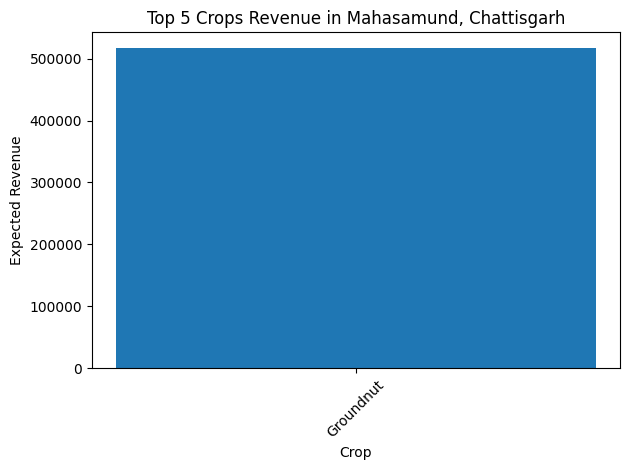

In [6]:
if result is not None:
    
    plt.figure()
    plt.bar(result["crop"], result["expected_revenue"])
    plt.xticks(rotation=45)
    plt.xlabel("Crop")
    plt.ylabel("Expected Revenue")
    plt.title(f"Top 5 Crops Revenue in {district_input}, {state_input}")
    plt.tight_layout()
    plt.show()


=== Average Expected Revenue by State ===


state
Kerala            1.162093e+06
Karnataka         5.297377e+05
Andhra Pradesh    4.474392e+05
Telangana         2.586845e+05
Chattisgarh       2.449194e+05
Tamil Nadu        2.323236e+05
Gujarat           1.930858e+05
West Bengal       1.726662e+05
Maharashtra       1.645862e+05
Odisha            1.548476e+05
Name: expected_revenue, dtype: float64

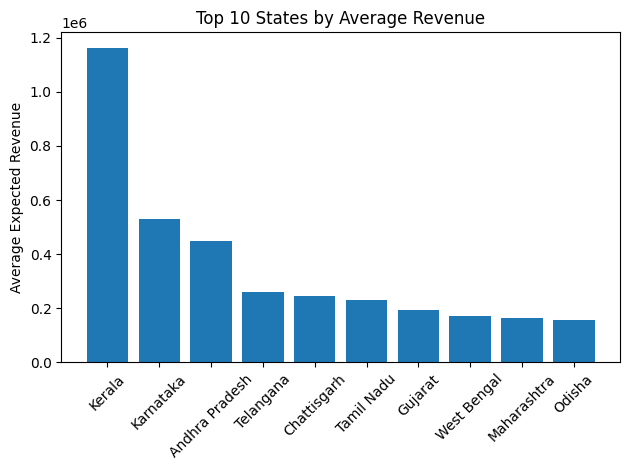

In [7]:
state_revenue = (
    ranking_df
    .groupby("state")["expected_revenue"]
    .mean()
    .sort_values(ascending=False)
)

print("\n=== Average Expected Revenue by State ===")
display(state_revenue.head(10))

plt.figure()
plt.bar(state_revenue.head(10).index,
        state_revenue.head(10).values)

plt.xticks(rotation=45)
plt.ylabel("Average Expected Revenue")
plt.title("Top 10 States by Average Revenue")
plt.tight_layout()
plt.show()


=== Top 10 Crops Across India (Avg Revenue) ===


crop
Black pepper    2.697080e+06
Coffee          8.712320e+05
Rubber          7.354398e+05
Turmeric        4.474392e+05
Groundnut       2.755339e+05
Cotton          2.673724e+05
Coconut         2.604435e+05
Mustard         2.358885e+05
Rice            1.677650e+05
Wheat           1.103769e+05
Name: expected_revenue, dtype: float64

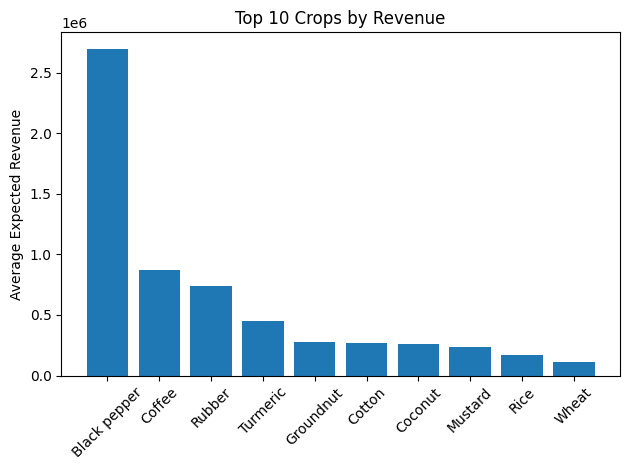

In [9]:
top_crops_overall = (
    ranking_df
    .groupby("crop")["expected_revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\n=== Top 10 Crops Across India (Avg Revenue) ===")
display(top_crops_overall)

plt.figure()
plt.bar(top_crops_overall.index,
        top_crops_overall.values)

plt.xticks(rotation=45)
plt.ylabel("Average Expected Revenue")
plt.title("Top 10 Crops by Revenue")
plt.tight_layout()
plt.show()